In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, re
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchdiffeq import odeint

import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch


# main_dir = "/home/wz369/rds/hpc-work/PINN_dynamics"
main_dir = "/Users/weizhongzheng/Documents/python_project/PINN_dynamics/"
os.chdir(main_dir)

In [3]:
import palantir
# import cellrank as cr
import scvelo as scv

In [4]:
sc.settings.set_figure_params(frameon=False, dpi=50, figsize=(3,3))

# load data

In [5]:
# # load dataset

adata = sc.read_h5ad(f'data/ery_mk_Aug1.h5ad')
tompos = sc.read_h5ad(f'data/tom_pos.h5ad')

In [669]:
adata.obs_names

Index(['9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x',
       '9mo_SIGAE3_AAACGAAGTAACAGGC-1-10x',
       '9mo_SIGAE3_AAACGAATCTACGGTA-1-10x',
       '9mo_SIGAE3_AAACGCTAGCGTTCAT-1-10x',
       '9mo_SIGAE3_AAACGCTTCCGTGCGA-1-10x',
       '9mo_SIGAE3_AAACGCTTCGCAGATT-1-10x',
       '9mo_SIGAE3_AAAGAACGTAGAGACC-1-10x',
       '9mo_SIGAE3_AAAGAACTCCTACTGC-1-10x',
       '9mo_SIGAE3_AAAGAACTCTAAACGC-1-10x',
       '9mo_SIGAE3_AAAGGATAGCGTGTCC-1-10x',
       ...
       '1261-SS2', '1267-SS2', '1268-SS2', '1271-SS2', '1274-SS2', '1276-SS2',
       '1281-SS2', '1282-SS2', '1285-SS2', '1286-SS2'],
      dtype='object', length=22739)

In [668]:
# known outlier
outlier_cbs = ['1079-SS2']
adata = adata[adata.obs_names in outlier_cbs].copy()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [8]:
adata.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1170
112     704
161     518
76      498
27      386
49      281
7       130
3       105
12       67
Name: count, dtype: int64

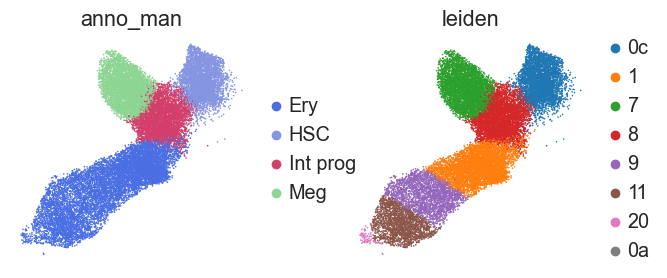

In [664]:
sc.pl.umap(adata, color=['anno_man','leiden'])

In [12]:
tompos.obs.query("`anno_man` == 'HSC'").sort_values('timepoint_tx_days')['timepoint_tx_days'].value_counts()

timepoint_tx_days
269    1943
112    1178
161     871
76      791
27      581
49      491
7       177
3       138
12       94
Name: count, dtype: int64

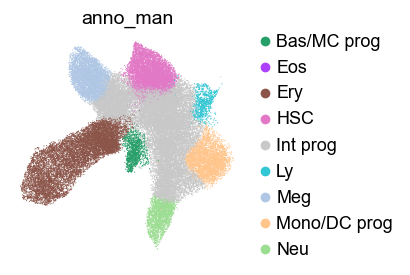

In [11]:
sc.pl.umap(tompos, color=['anno_man'])

# load density transport results

In [18]:
from PINN.models import DT_analysis

## Exp configs

In [35]:
def check_non_zero_prop(TM):
    "For transport matrix at given time, check non zeros transport"

    ncell = TM.shape[0]
    TM_flat = TM.reshape(ncell,-1)
    nz =  np.sum(TM_flat.sum(axis=1) != 0) # count non zero cells

    return nz / ncell


In [57]:
# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n7_minminus/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config

cell type proportion summary detected
adding to  ct_prop property
2
(946, 100)
(945, 100)


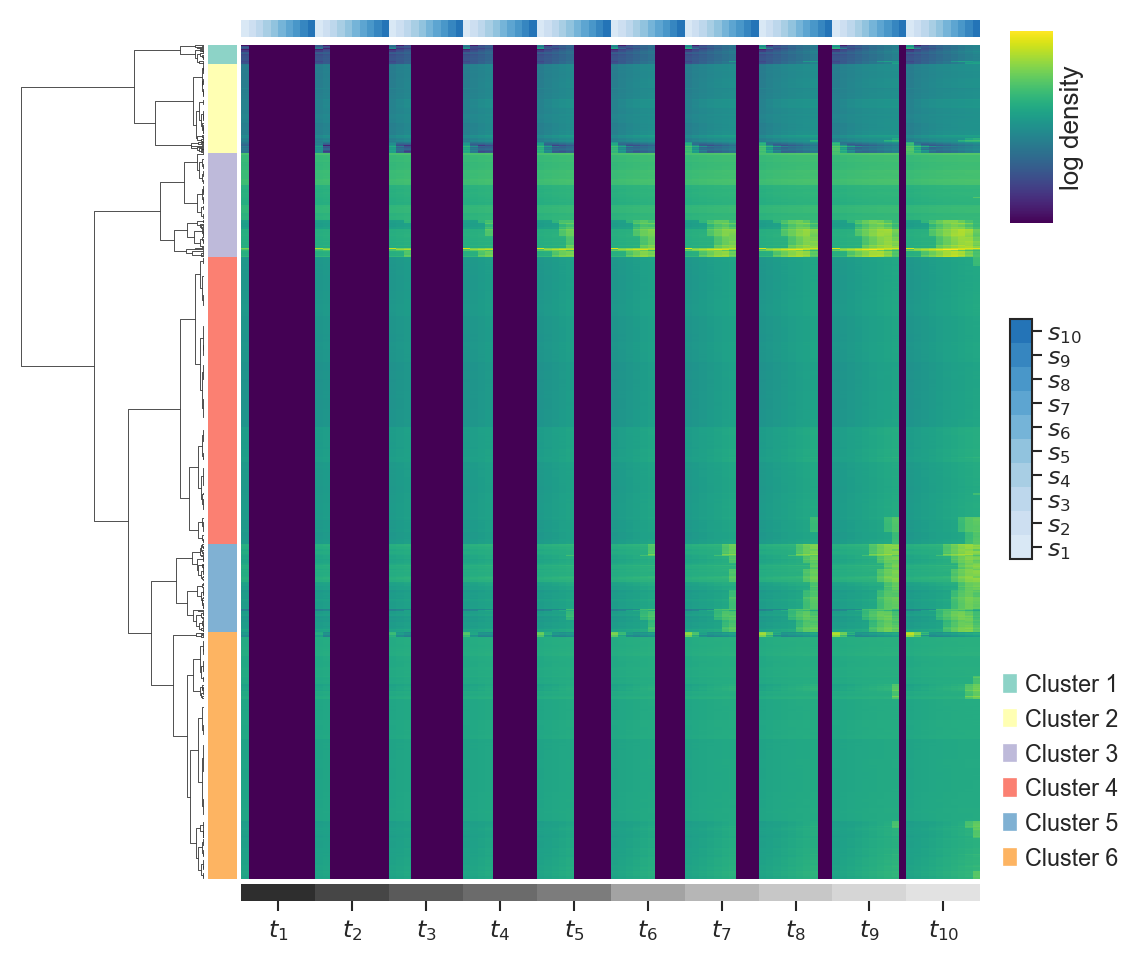

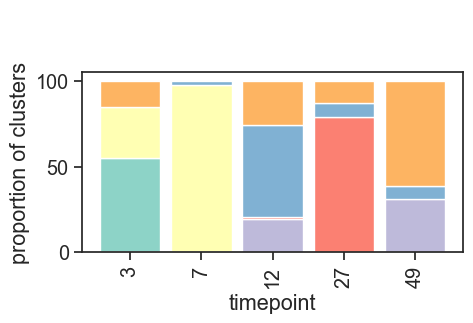

In [736]:
# test new dt func : duds 

# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config



Int_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_x = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_y = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

v = '2'

# for num_clusters in [5,6,7, 8]:

timepoints = ['0-4', '4-9',  '9-24', '24-46', '46-73' ]

v = '2'

for num_clusters in [6]:  
    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "Int prog")
    print(v)
    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

    # T_M_full = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100)
    T_M_full = Tmap_all.reshape(-1,100)

    # log 
    matrix_raw = T_M_full.copy()
    matrix_log = np.log(T_M_full+1e-20)
    T_M_full = matrix_log
    T_M_full = np.where(matrix_raw == 0, 0, matrix_log-matrix_log.min())
    print(T_M_full.shape)
    T_M_full = T_M_full[[i for i in range(T_M_full.shape[0]) if i not in [18]]]
    print(T_M_full.shape)
    # PLOT
    # if T_M_full.sum()>0:
    cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
        num_clusters, 
        original_shape = (10,10),
        truncate_mode="level", p=4, 
        cluster_colors=None, 
        show_log=False,
        context_kws = {"figure.dpi":60},
        col_colorbar_size=(0.02, 0.25), 
        col_colorbar_location_x = (0.95, 0.4), 
        col_colorbar_location_y = (1.03, 0.4), 
        col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
        col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
        cbar_kws = {'label':'log density', 'ticks':[]}
        )
    # g.ax_col_colors.set_title(v)

    result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
    g.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}.svg"), transparent=True, dpi=600)

    # CB LIST
    cb_list = []
    for t in timepoints:# , '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list).tolist() 
    cb_list.remove(outlier_cbs[0])

    fig, axs = DT.cluster_proportion(cluster_flat, cb_list)
    fig.savefig(os.path.join(result_dir, f"DenTransport_MEP_c{num_clusters}_cluster_proportion.svg"), transparent=True, dpi=600)
    # SAVE DT analysis
    Int_DT_dict[v] = DT
    

In [750]:
T_M_full

array([[43.09628727,  0.        ,  0.        , ..., 44.78956305,
        45.58672973, 45.82676173],
       [45.18027166,  0.        ,  0.        , ..., 45.54783535,
        45.70434456, 45.84352721],
       [42.85365163,  0.        ,  0.        , ..., 46.07112474,
        45.99526263, 45.60771531],
       ...,
       [46.95568295,  0.        ,  0.        , ..., 47.14859352,
        47.15858045, 47.16606383],
       [46.18408551,  0.        ,  0.        , ..., 46.37618457,
        46.38648528, 46.39447354],
       [46.47459476,  0.        ,  0.        , ..., 48.58891594,
        48.14192044, 47.36207207]], shape=(945, 100))

IndexError: list index out of range

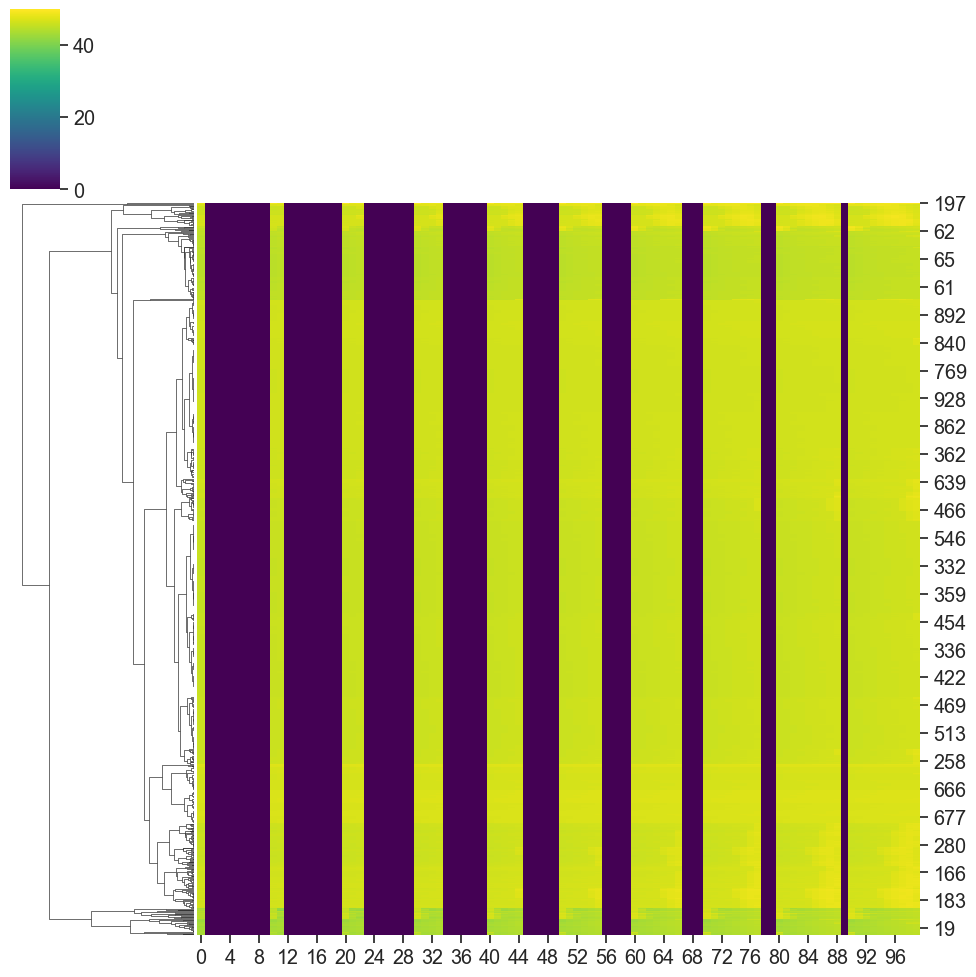

In [751]:
g = sns.clustermap(T_M_full, cmap='viridis', col_cluster=False)

# Retrieve the normalizer from the heatmap
norm = g.ax_heatmap.images[0].norm

In [672]:
np.where(cluster_flat == 3)

(array([18]),)

In [659]:
cb_list[np.where(cluster_flat == 3)[0]]

array(['1079-SS2'], dtype='<U40')

<Axes: >

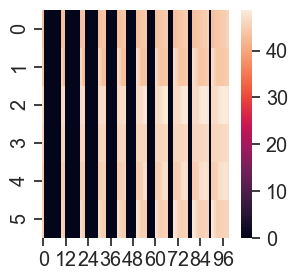

In [756]:
all_flat_tm = np.concatenate(list(TM_cluster.values())).reshape(-1,100)
sns.heatmap(all_flat_tm,
            )

In [771]:
TM_ci.max()

np.float64(45.108981699949666)

In [ ]:
# DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2/Density_transport", 
#                      "Int prog")
# Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

TM_cluster = {}
# vmax = 0.1
# vmin = 99
for i in range(1,7):
    N_TM = np.sum(cluster_flat == i)
    TM_ci = T_M_full[cluster_flat == i][np.random.randint(0, N_TM)]

    # TM_ci = T_M_full[cluster_flat == i].mean(axis=0)
    TM_cluster[str(i)] = TM_ci.reshape(10,10)
    # vmax = np.max([vmax, TM_ci.max().item()])
    # vmin = np.min([vmin, TM_ci[TM_ci!=0].min().item()])

In [ ]:
vmax = 47.89

np.float64(47.89645674386911)

In [ ]:
vmin = 42.93

np.float64(42.93968077326968)

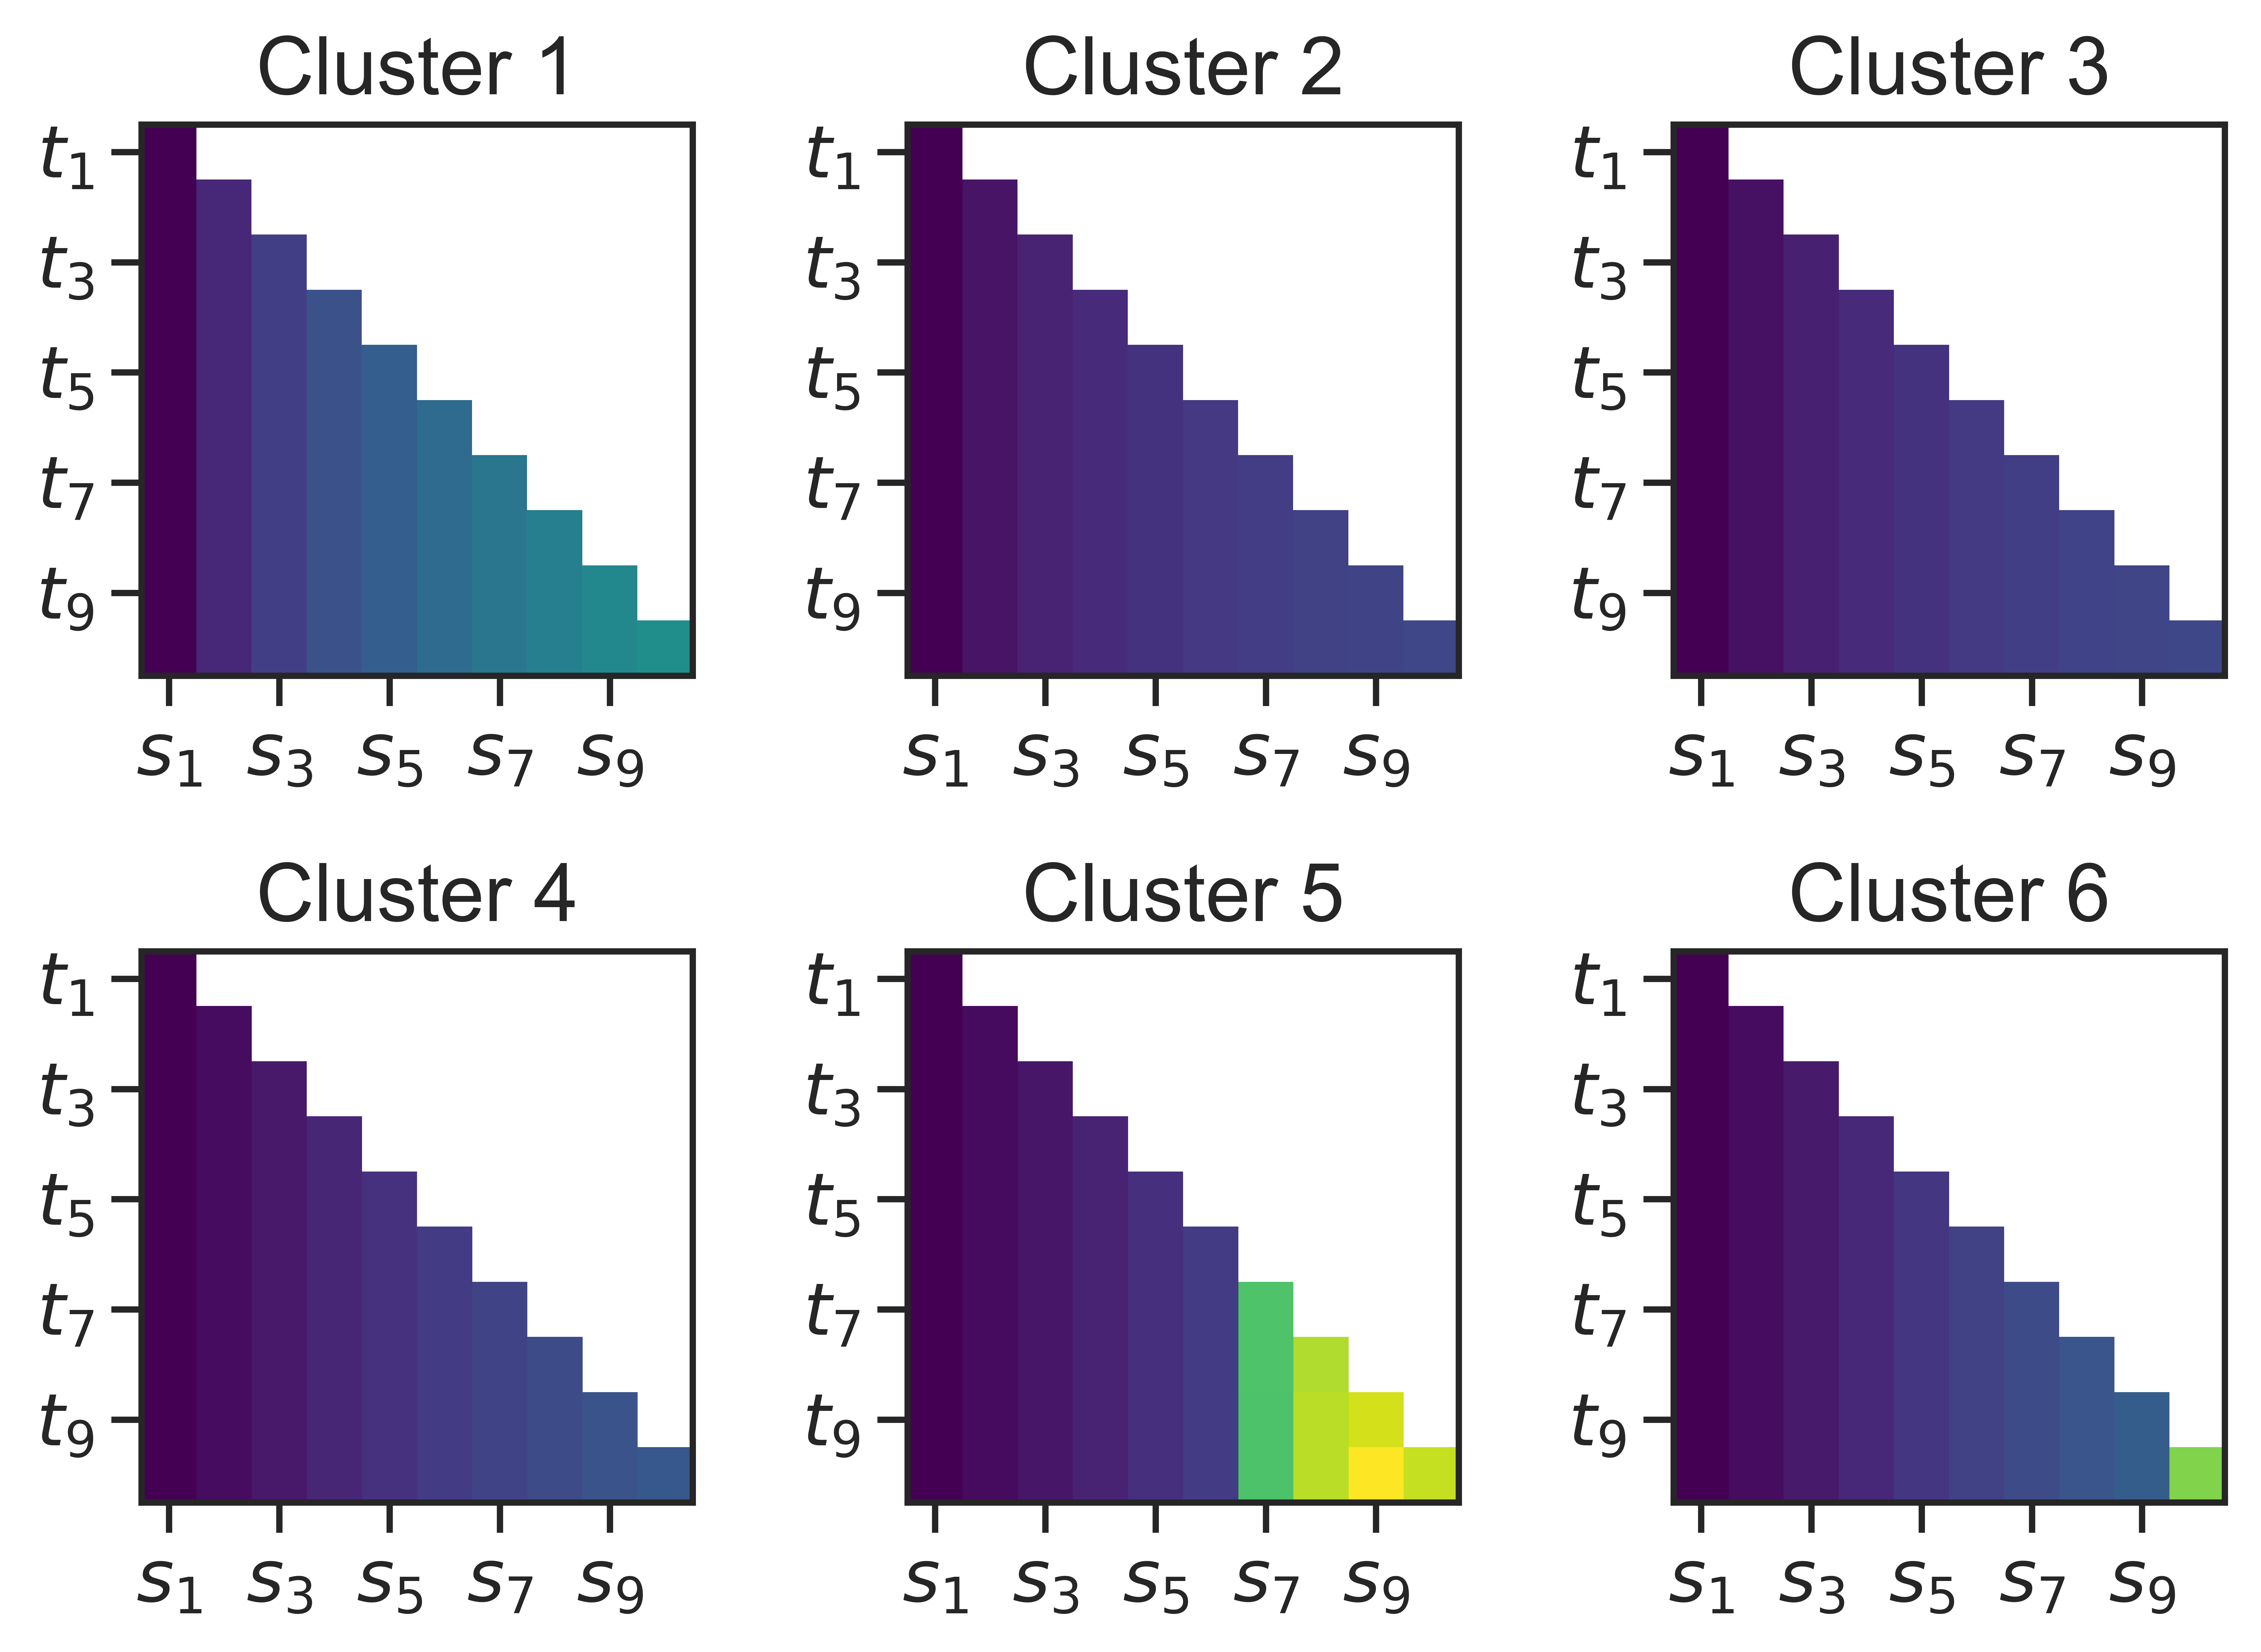

In [799]:
nrow = 2
ncol = 3

fig, axs = plt.subplots(nrow, ncol, figsize=(2.5*ncol, 2.5*nrow), dpi=600, 
                        frameon=False, gridspec_kw={"hspace":0.5, 'wspace':0.3})
axs = axs.flatten()

for i in range(1,7):
    N_TM = np.sum(cluster_flat == i)
    TM_ci = T_M_full[cluster_flat == i][np.random.randint(0, N_TM)]
    TM_cluster[str(i)] = TM_ci.reshape(10,10)

# for it, T in enumerate(Tmap_ct_t[ct]):
it = 0
for cluster, TM in TM_cluster.items():

    T_values = T_M_full[np.logical_and(T_M_full!=0, ~np.isnan(T_M_full))]
    

    # PINN.pl.plot_tmap(TM, ax=axs[ it], log=False, 
    #              vmax=np.log(T_values.max()), vmin=np.log(T_values.min()/5))
    
    trui = np.triu_indices_from(TM, k=1)
    TM[trui] = np.nan
    axs[it].matshow(TM, cmap='viridis', vmax= vmax)

    t = adata.uns['pop']['t'][it]
    tp1 = adata.uns['pop']['t'][it+1]

    axs[it].set_title(f"Cluster {cluster}", fontsize=16)

    axs[it].set_yticks(np.arange(0,10,2))
    axs[it].set_yticklabels([r"$t_1$", r"$t_3$", r"$t_5$", r"$t_7$", r"$t_9$"])
    
    axs[it].tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
    axs[it].set_xticks(np.arange(0,10,2))
    axs[it].set_xticklabels([r"$s_1$", r"$s_3$", r"$s_5$", r"$s_7$", r"$s_9$"])


    it += 1

# axs[-1].axis("off")

# fig.savefig(os.path.join(result_dir, "density_transfer_example_matrix.svg"), transparent=True, dpi=600)

In [707]:
np.nanmax(TM),  np.nanmin(TM)

(np.float64(46.608406327481724), np.float64(46.087472465007565))

In [ ]:
cb_list = []
for t in ['0-4', '4-9',  '9-24', '24-46', '46-73', '73-109', '109-158']:
    cb_list.append(DT.cb_dict[t])

cb_list = np.concatenate(cb_list)

cell type proportion summary detected
adding to  ct_prop property
2
(969, 100)


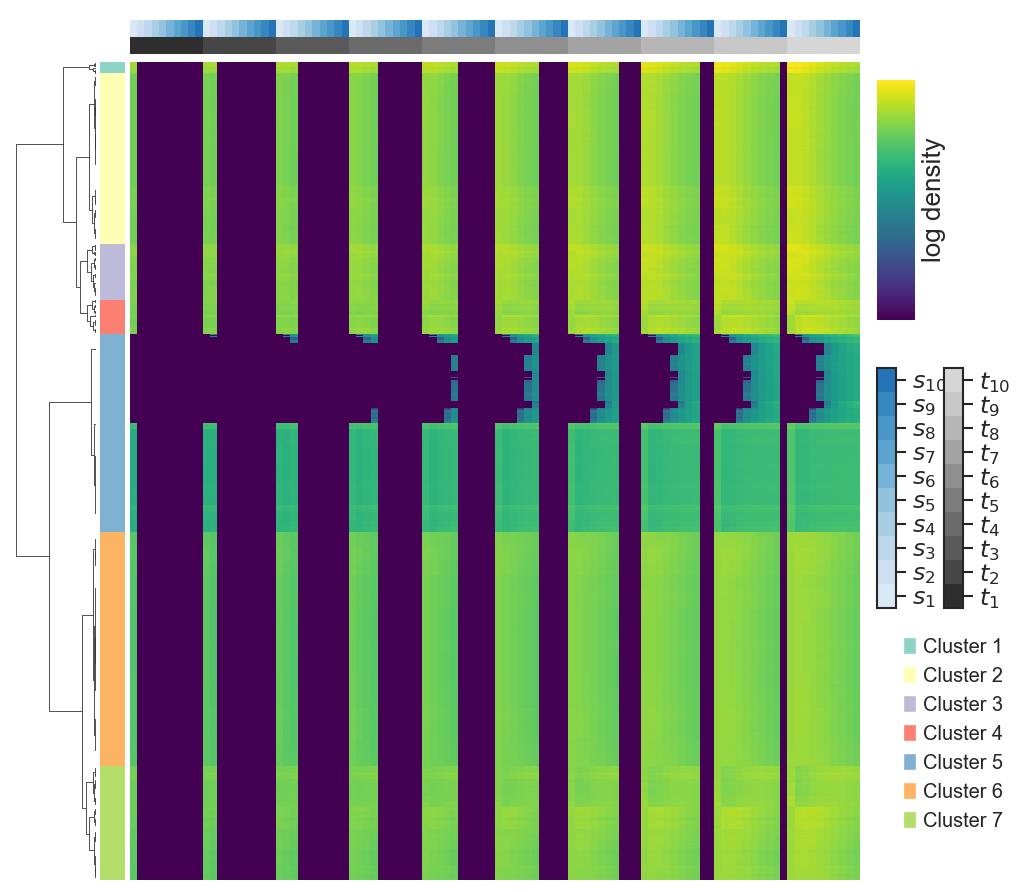

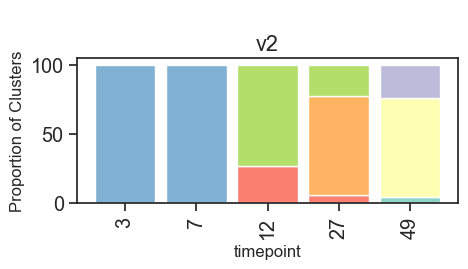

In [518]:
# test new dt func : duds 



HSC_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_x = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_y = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

# num_clusters = 7
# for v in config_dict:

v = '2'

for num_clusters in [7]:    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "HSC")
    print(v)

    # CB LIST
    order_days = ['0-4', '4-9',  '9-24', '24-46', '46-73']
    
    cb_list = []
    for t in ['0-4', '4-9',  '9-24', '24-46', '46-73']:#, '73-109', '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list)

    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in order_days], axis=0)
    # T_M_full = np.transpose(Tmap_all, axes=[0,2,1])
    T_M_full = Tmap_all.reshape(-1,100)
    print(T_M_full.shape)


    # PLOT
    if T_M_full.sum()>0:
        cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
            num_clusters, 
            original_shape = (10,10),
            truncate_mode="level", p=4, 
            cluster_colors=None, 
            show_log=True,
            context_kws = {"figure.dpi":60},
            col_colorbar_size=(0.02, 0.25), 
            col_colorbar_location_x = (0.93, 0.35), 
            col_colorbar_location_y = (1., 0.35), 
            col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
            col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
            cbar_kws = {'label':'log density', 'ticks':[]}
            )
        
    c4s = cluster_flat[cluster_flat == 4]
    # cb_list.append(
    #     adata.obs[celltype].loc[c4s.index].to_numpy()
    # )
    
    

    adata.obs['HSC_cluster_flat'] = 'na'
    named_cluster_flats = ['HSC_c%s'%c for c in cluster_flat]
    adata.obs.loc[cb_list, 'HSC_cluster_flat'] = named_cluster_flats


    sns.set_theme(font_scale=1.3, style='ticks', palette='Set3')
    fig, ax = PINN.pl.obs_composition(
                adata[cb_list], 
                'timepoint_tx_days', 'HSC_cluster_flat', 
                figkws={'figsize':[5,3.5]},
                legend_kws={"handles":[], "frameon":False,  "fontsize":13 ,'ncol':3, "bbox_to_anchor":(0.05, 1.4), "loc":'upper left', }
                )
    ax.set_title(f"v{v}")

    ax.set_xlabel("timepoint", fontsize=12)
    ax.set_ylabel("Proportion of Clusters", fontsize=12)


    # SAVE DT analysis
    HSC_DT_dict[v] = DT

2


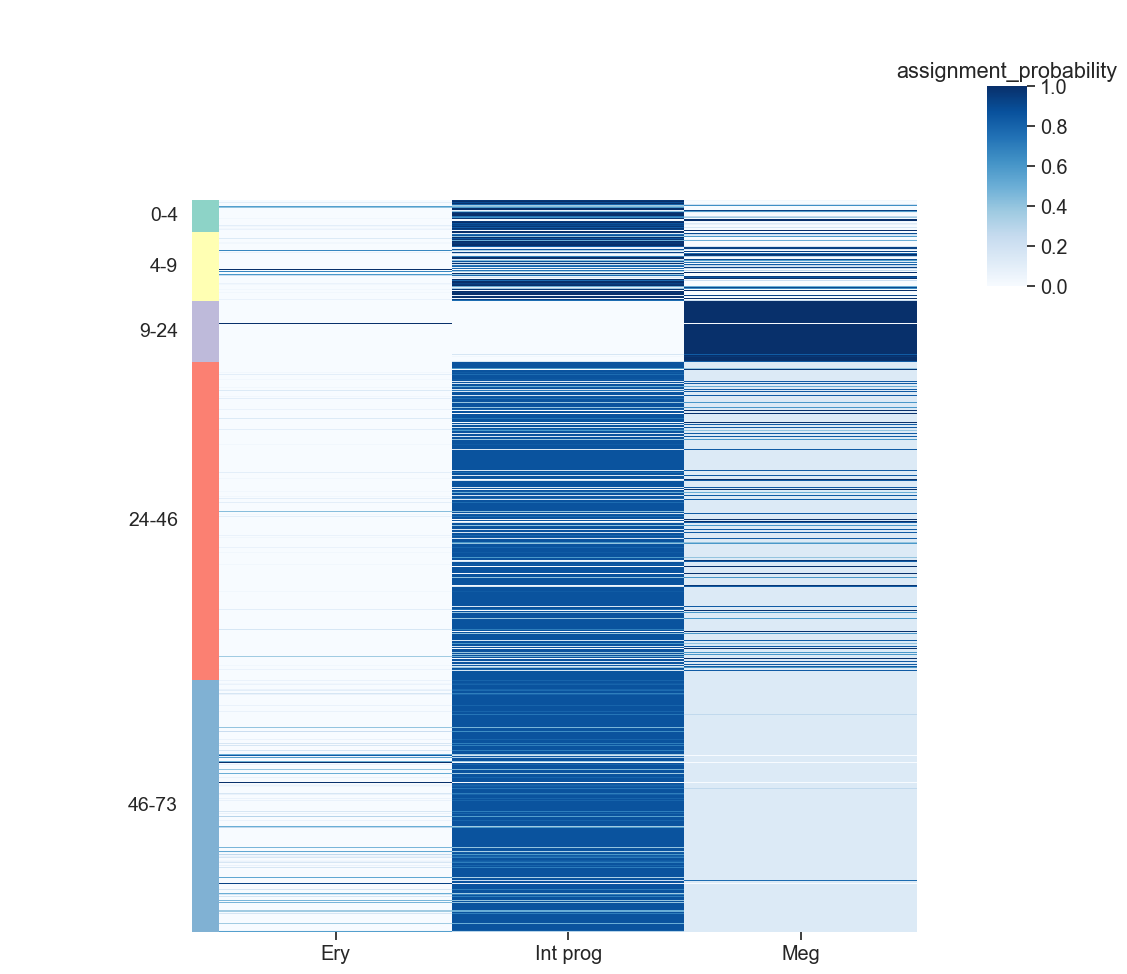

In [513]:
import time
for v,DT in Int_DT_dict.items():
    print(v)
    g = DT.heatmap_cell_proportions(['Ery', 'Int prog', 'Meg'],
                                     step=-3,
                                     cbar_pos = [1,0.7,0.04,0.2],
                                     cmap='Blues'
                                     )
    g

# aggregated density

In [309]:
from matplotlib import cm

In [639]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

cmap = plt.get_cmap('bone_r')
new_cmap = truncate_colormap(cmap, 0.01, 0.6)
# new_cmap = 'Blues'

In [714]:
outlier_cbs

['1079-SS2']

In [720]:
clean_cb = [cb for cb in DT.agg_density.index if cb not in outlier_cbs]
DT.agg_density = DT.agg_density.loc[clean_cb].copy()

In [728]:
DT.agg_density.Day.unique()

array(['4-9', '46-73', '24-46', '9-24', '0-4'], dtype=object)

In [ ]:
realt_mapper = dict(zip(['4-9', '46-73', '24-46', '9-24', '0-4'], ['7-12', '49-76', '27-49', '12-27', '3-7']))

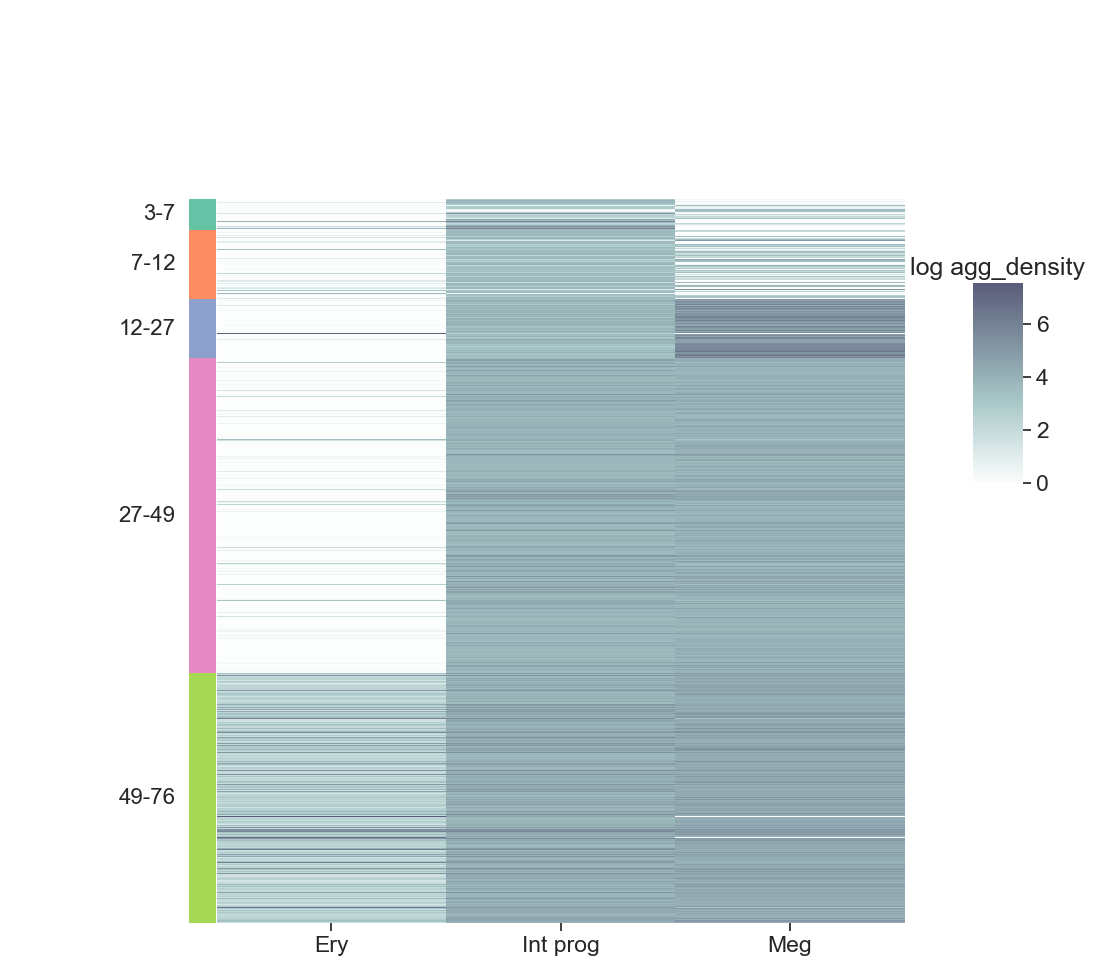

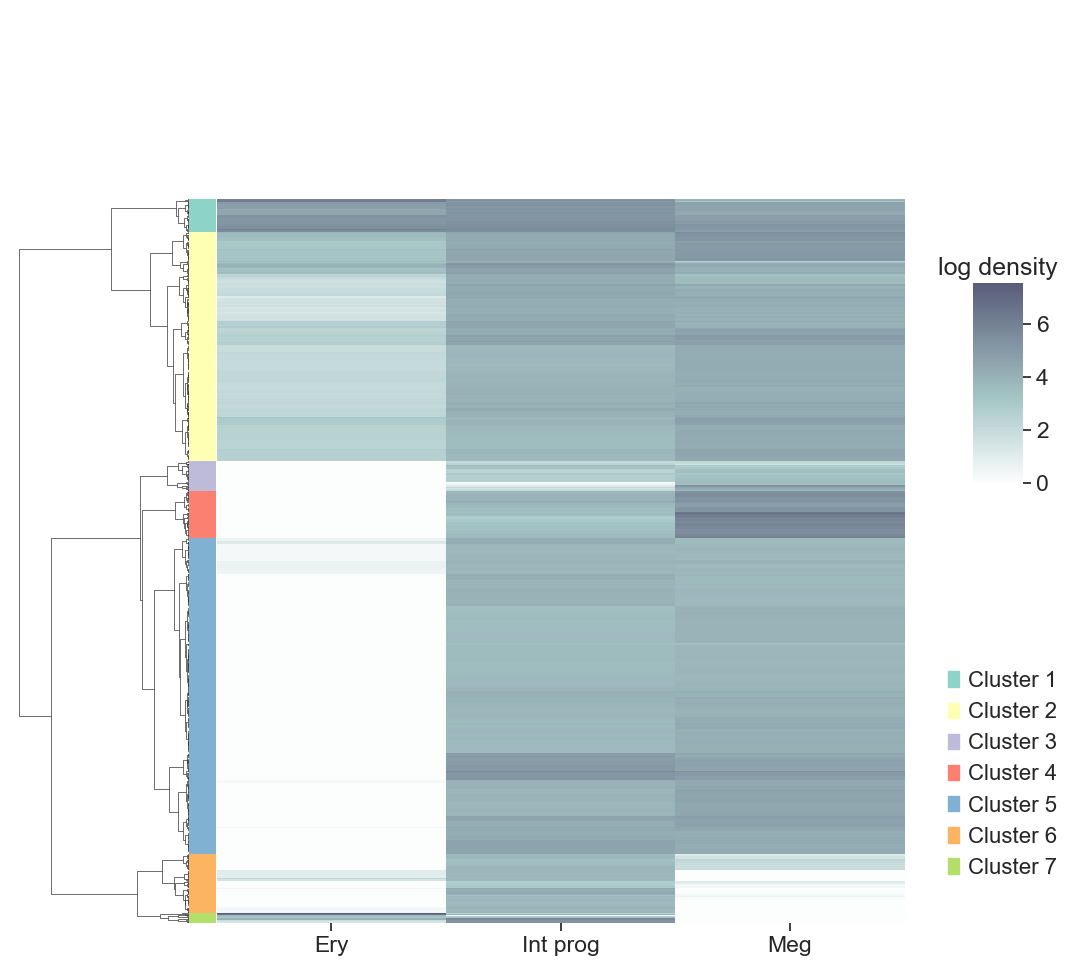

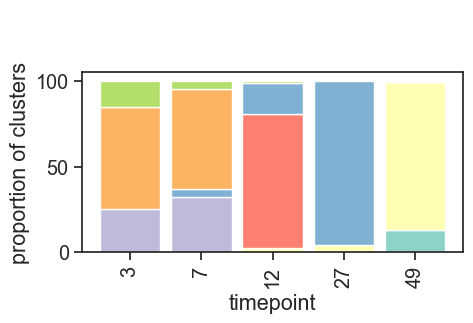

In [735]:
DT = Int_DT_dict['2']

log_normalize = True
n_clusters = 7
celltypes = ['Ery', 'Int prog', 'Meg']
value='agg_density'
cmap = new_cmap

DT.density_by_celltype_step(celltypes=celltypes, step=-1, norm=True)
DT.agg_density = DT.agg_density.loc[clean_cb].copy()
DT.agg_density['Day'] = DT.agg_density.Day.map(realt_mapper)

sns.set_theme(style='ticks', font_scale=1.5)
g = DT.heatmap_cell_proportions(celltypes=celltypes, value=value,  log_normalize=log_normalize, cmap=cmap,
                                cbar_pos=[0.99, 0.5, 0.05,0.2])
# g.ax_heatmap.set_yticks([])
# g.ax_heatmap.set_title("transported density grouped by celltype", pad=30, fontsize=20)


celltypes = ['Ery','Int prog','Meg']
clusters, row_linkage, _ = DT.hierarchical_clustering(celltypes=celltypes, value=value,  log_normalize=log_normalize,  n_clusters=n_clusters)


g2 = DT.clustermap(
                clusters, row_linkage,
                celltypes=celltypes, value=value,  
                log_normalize=log_normalize, cmap=cmap,
                cbar_pos=[0.99, 0.5, 0.05,0.2],
                figsize=(10,10),
                )

cellbarcodes = DT.agg_density.index
figprop, axs = DT.cluster_proportion(clusters, cellbarcodes)


result_dir = 'results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_2'
log_name = ['', 'log '][log_normalize]

g.savefig(os.path.join(result_dir, f'{value}_celltype_timemap_c{n_clusters}{log_name}.svg'), 
          dpi=600, transparent=True)

g2.savefig(os.path.join(result_dir, f'{value}_celltype_clustermap_c{n_clusters}{log_name}.svg'), 
          dpi=600, transparent=True)

figprop.savefig(os.path.join(result_dir, f'{value}_celltype_cluster_bar_c{n_clusters}{log_name}.svg'), 
          dpi=600, transparent=True)

In [472]:
DT.ct_prop.query("`Day` == '0-4'").copy()

,Unnamed: 0,Ery,HSC,Int prog,Meg,Day,step,cell_index
0,0,0.0,0.0,0.033333,0.966667,0-4,1,0
1,0,0.0,0.0,0.100000,0.900000,0-4,2,0
2,0,0.0,0.0,0.133333,0.866667,0-4,3,0
3,0,0.0,0.0,0.100000,0.900000,0-4,4,0
4,0,0.0,0.0,0.066667,0.933333,0-4,5,0
...,...,...,...,...,...,...,...,...
405,40,0.0,0.0,0.966667,0.033333,0-4,6,40
406,40,0.0,0.0,1.000000,0.000000,0-4,7,40
407,40,0.0,0.0,1.000000,0.000000,0-4,8,40
408,40,0.0,0.0,0.966667,0.033333,0-4,9,40


# Result for `ery_mk_Aug1_multiscaled_n6`

<font size=1>  
 
```python

# test new dt func : duds 

# find all config files
config_dir = "logs/ery_mk_Aug1_multiscaled_n6/pde_params_tsense/"
configs = [file for file in os.listdir(config_dir) if file.endswith('.json')]

# load config for different runs
config_dict = {}
for js in configs:
    version = js.split("_")[0][1:] # after V
    config = PINN.ExperimentConfig(os.path.join(config_dir, js))
    config.from_json(os.path.abspath(os.path.join(config_dir, js)), main_dir)
    config_dict[version] = config

num_clusters = 5

Int_DT_dict = {}



# ticklabels for heat map
col_colorbar_tick_labels_y = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_x = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

v = '2'

# for num_clusters in [5,6,7, 8]:

timepoints = ['0-4', '4-9',  '9-24', '24-46', '46-73' ]

for v in config_dict:
    
    # LOAD DT
    DT = DT_analysis(adata, f"results/ery_mk_Aug1_multiscaled_n6/pde_params_tsense_{v}/Density_transport", 
                     "Int prog")
    print(v)
    Tmap_all = np.concatenate([DT.TM_norm_dict[t] for t in timepoints], axis=0)

    T_M_full = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100)
    print(T_M_full.shape)

    # log 
    matrix_raw = T_M_full.copy()
    matrix_log = np.log(T_M_full+1e-20)
    T_M_full = np.where(matrix_raw == 0, 0, matrix_log-matrix_log.min())

    # PLOT
    # if T_M_full.sum()>0:
    cluster_flat, reordered_indices, g = PINN.pl.truncated_clustermap(T_M_full, 
        num_clusters, 
        original_shape = (10,10),
        truncate_mode="level", p=4, 
        cluster_colors=None, 
        show_log=False,
        context_kws = {"figure.dpi":60},
        col_colorbar_size=(0.02, 0.25), 
        col_colorbar_location_x = (0.93, 0.35), 
        col_colorbar_location_y = (1., 0.35), 
        col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
        col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
        cbar_kws = {'label':'log density', 'ticks':[]}
        )
    g.ax_col_colors.set_title(v)
    g.fig

    # CB LIST
    cb_list = []
    for t in timepoints:# , '109-158']:
        cb_list.append(DT.cb_dict[t])
    cb_list = np.concatenate(cb_list)

    adata.obs['HSC_cluster_flat'] = 'na'
    named_cluster_flats = ['Cluster%s'%c for c in cluster_flat]
    adata.obs.loc[cb_list, 'HSC_cluster_flat'] = named_cluster_flats


    sns.set_theme(font_scale=1.3, style='ticks', palette='Set3')
    with plt.rc_context({"figure.dpi":100, "figure.figsize":(4,4)}):
        fig, ax = PINN.pl.obs_composition(
                    adata[cb_list], 
                    'timepoint_tx_days', 'HSC_cluster_flat', 
                    figkws={'figsize':[5,4]},
                    legend_kws={"handles":[], "frameon":False,  "fontsize":13 ,'ncol':3, "bbox_to_anchor":(0.05, 1.4), "loc":'upper left', }
                    )
        ax.set_title(v)

    ax.set_xlabel("timepoint", fontsize=12)
    ax.set_ylabel("Proportion of Clusters", fontsize=12)


    # SAVE DT analysis
    Int_DT_dict[v] = DT
``` 
  
</font>

**HSC for n6**

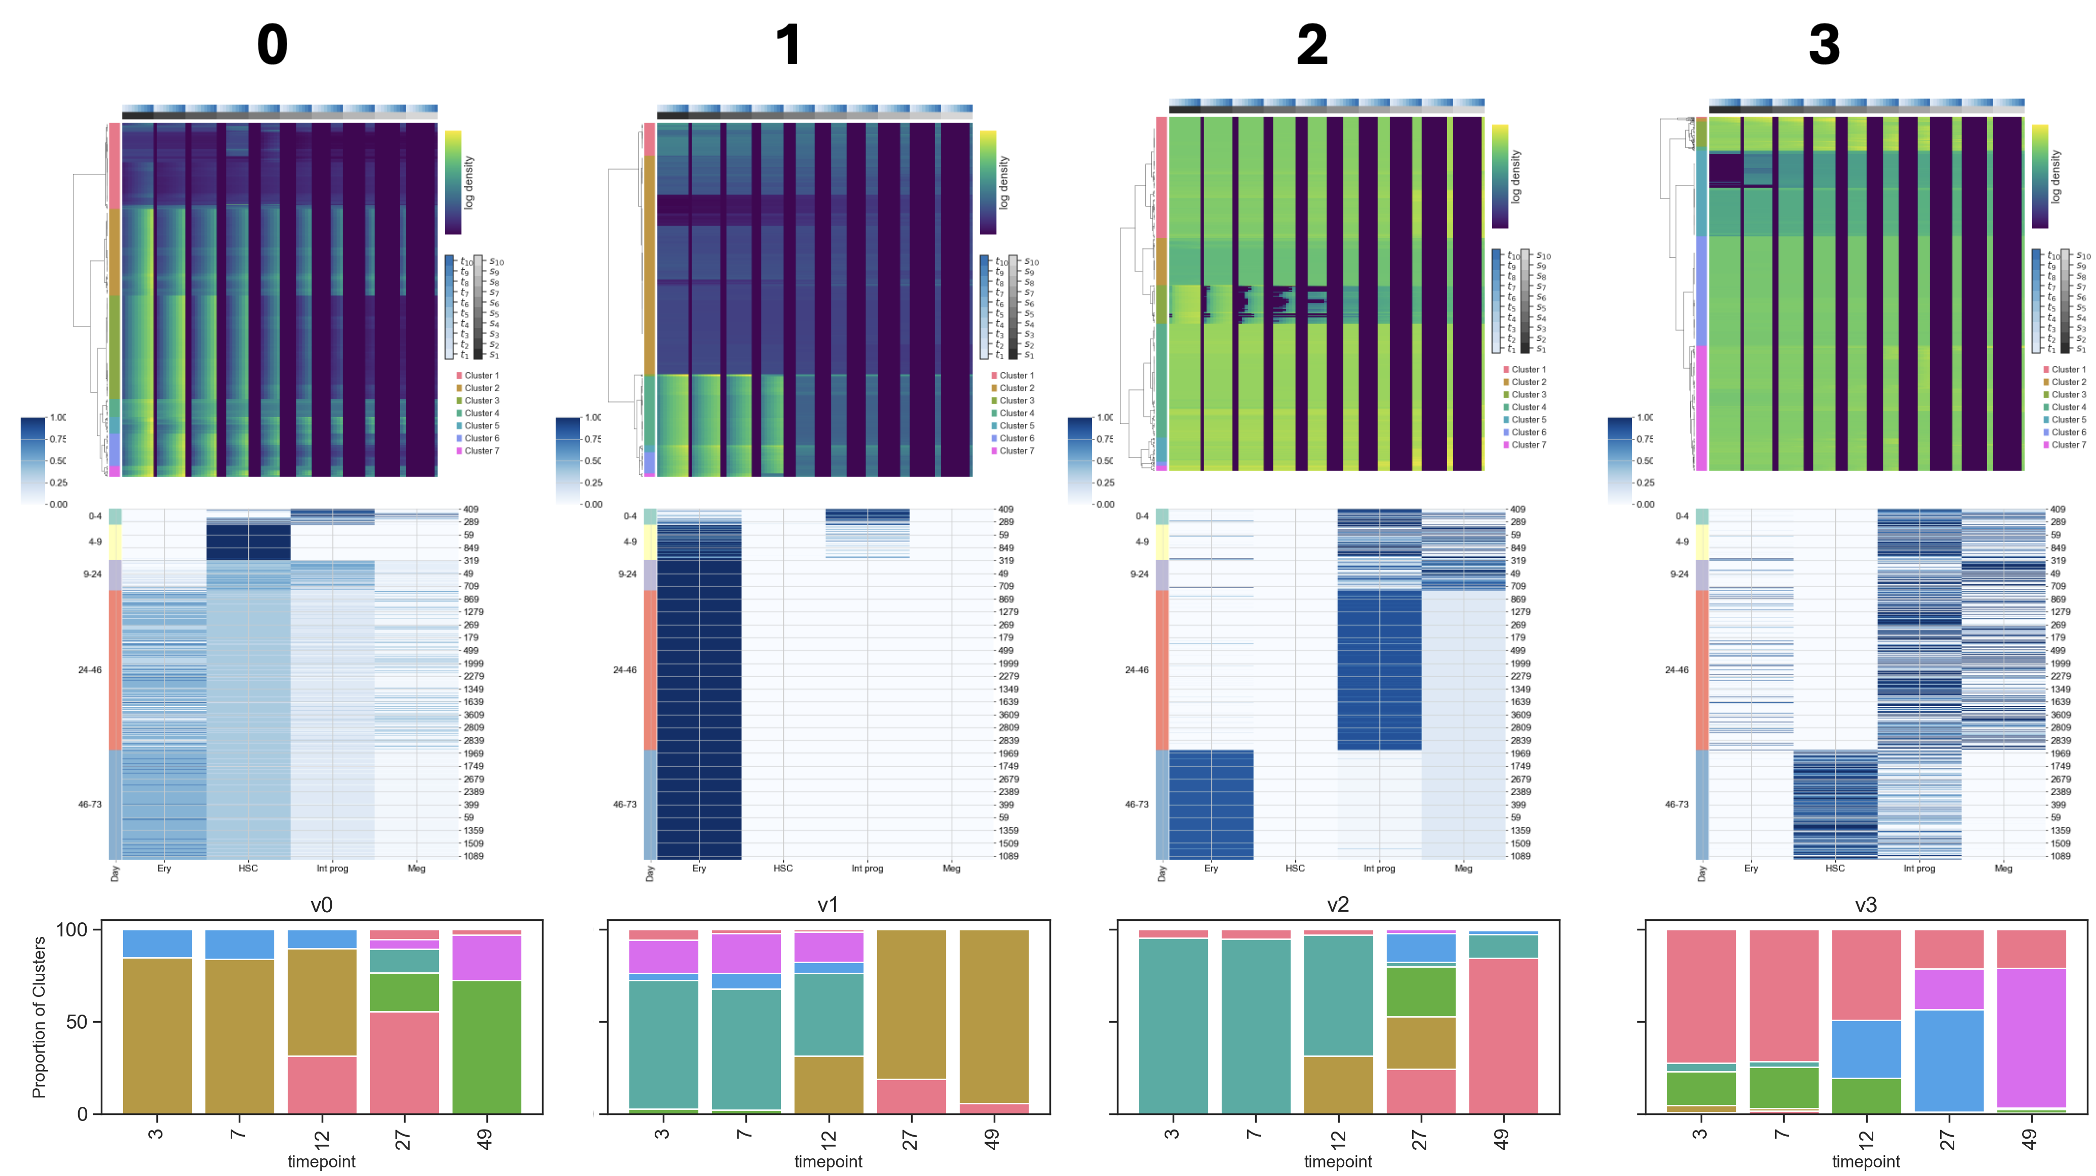

**Int prog for n6**
  
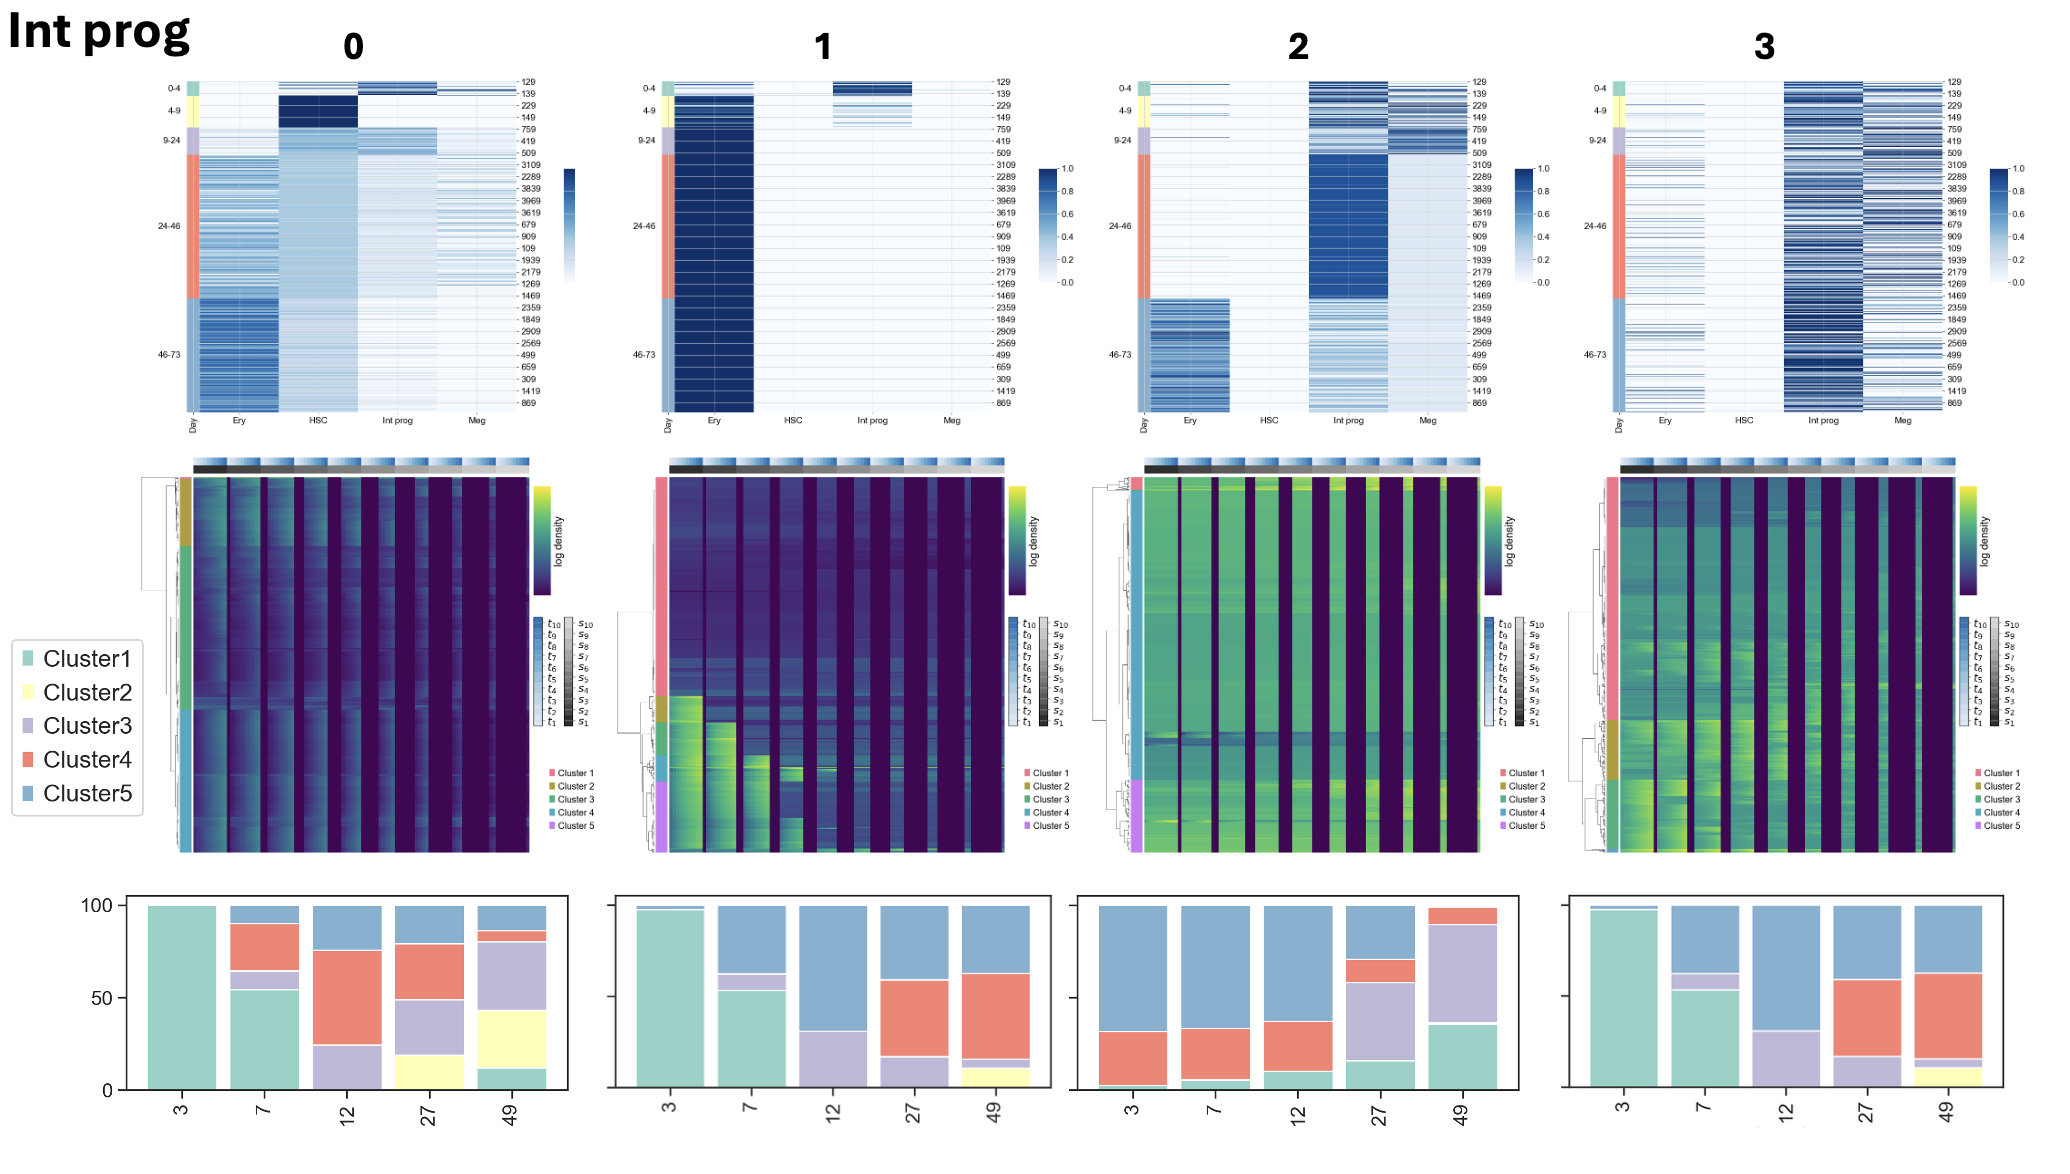

# Density transport and celltype for every s along the trajectory